# Chapter 13 Bayesian Approaches to Gradient Boosting: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-13-bayesian-boosting-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

Chapter 9 turned a regression coefficient into a posterior distribution with a single choice
of prior. Chapter 12 turned a random forest into BART by putting a regularizing prior on tree
structure and leaf values, then sampling the ensemble with MCMC.

Gradient boosting resists the same move. It is worth being specific about why, before looking
at what a Bayesian practitioner does instead.

In [1]:
import os
import numpy as np
import plotly.graph_objects as go
from scipy.stats import norm

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(11)

`true_loss` is a helper used by the figures below.

In [4]:
def true_loss(lr, depth):
    lr_opt, depth_opt = 0.08, 4.0
    bowl = 6.0 * (lr - lr_opt) ** 2 + 0.02 * (depth - depth_opt) ** 2
    trap = 0.35 * np.exp(-((lr - 0.25) ** 2) / 0.002 - ((depth - 7.5) ** 2) / 1.5)
    return 0.18 + bowl - trap

## Bayesian hyperparameter optimization

A Bayesian search's trials on a simulated validation-loss surface, learning rate vs. max depth. Early trials spread out to explore; later trials cluster around the region that turns out to be promising. Move the slider.

In [5]:
def fig_bo_search_trajectory() -> go.Figure:
    lr_grid = np.linspace(0.01, 0.35, 45)
    depth_grid = np.linspace(1, 10, 45)
    LR, DEPTH = np.meshgrid(lr_grid, depth_grid)
    Z = true_loss(LR, DEPTH)

    # A simple GP-surrogate-driven search: start with 4 random points, then repeatedly pick
    # the untried grid point with the highest expected improvement given the surrogate's
    # (noisy) belief, refit the belief, and repeat. This is a simplified but working EI
    # loop, not a scripted path.
    candidates = np.column_stack([LR.ravel(), DEPTH.ravel()])

    trial_lr = list(RNG.uniform(0.01, 0.35, 4))
    trial_depth = list(RNG.uniform(1, 10, 4))
    trial_loss = [float(true_loss(a, b)) for a, b in zip(trial_lr, trial_depth)]

    def gp_predict(x_train, y_train, x_query, length_scale=0.5, noise=0.01):
        x_train = np.asarray(x_train)
        x_query = np.asarray(x_query)

        def kernel(a, b):
            d2 = ((a[:, None, 0] - b[None, :, 0]) / 0.08) ** 2 + (
                (a[:, None, 1] - b[None, :, 1]) / 2.5
            ) ** 2
            return np.exp(-0.5 * d2 / length_scale**2)

        K = kernel(x_train, x_train) + noise * np.eye(len(x_train))
        K_s = kernel(x_train, x_query)
        K_ss_diag = np.ones(len(x_query))
        K_inv = np.linalg.inv(K)
        mu = K_s.T @ K_inv @ np.array(y_train)
        var = K_ss_diag - np.einsum("ij,jk,ik->i", K_s.T, K_inv, K_s.T)
        return mu, np.clip(var, 1e-8, None)

    n_trials_total = 16
    while len(trial_lr) < n_trials_total:
        x_train = np.column_stack([trial_lr, trial_depth])
        mu, var = gp_predict(x_train, trial_loss, candidates)
        sigma = np.sqrt(var)
        best_so_far = min(trial_loss)
        improvement = best_so_far - mu
        z = improvement / sigma
        ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
        next_idx = int(np.argmax(ei))
        nlr, ndepth = candidates[next_idx]
        trial_lr.append(float(nlr))
        trial_depth.append(float(ndepth))
        trial_loss.append(float(true_loss(nlr, ndepth)))

    # The contour is a static background layer, added once as trace 0 and never touched by
    # the animation. Animating a Contour trace inside go.Frame is unreliable in Plotly.js: on
    # some frame transitions the filled contour fails to repaint even though it stays
    # hoverable. Only the scatter (trace 1) is redrawn per frame, which avoids the bug entirely.
    # z/x/y are cast to plain lists: plotly.py 6.x serializes numpy arrays into a compact
    # {dtype, bdata} binary payload that some Plotly.js CDN builds fail to decode for Contour
    # traces, leaving the background blank. Plain lists always serialize as a normal JSON array.
    contour_trace = go.Contour(
        x=lr_grid.tolist(), y=depth_grid.tolist(), z=Z.tolist(), colorscale="Blues_r",
        showscale=False, opacity=0.85,
        contours=dict(showlines=False),
    )

    frames = []
    for k in range(4, n_trials_total + 1):
        frames.append(
            go.Frame(
                name=str(k),
                data=[
                    go.Scatter(
                        x=trial_lr[:k], y=trial_depth[:k], mode="markers+text",
                        text=[str(i + 1) for i in range(k)], textposition="top center",
                        marker=dict(size=10, color="#F58518", line=dict(width=1, color="white")),
                        name="trials evaluated",
                    ),
                ],
                traces=[1],
            )
        )

    fig = go.Figure(data=[contour_trace, frames[0].data[0]], frames=frames)
    fig.update_layout(
        title="Bayesian hyperparameter search over learning rate and max depth",
        xaxis_title="learning rate",
        yaxis_title="max tree depth",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Trials evaluated: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300},
                                      "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

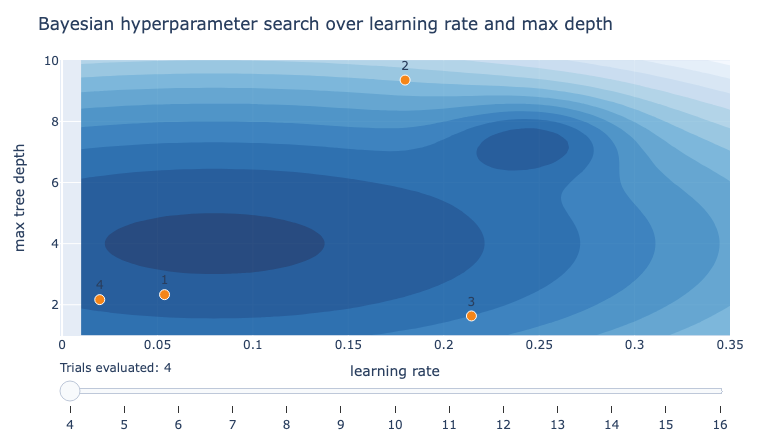

In [6]:
show(fig_bo_search_trajectory())

## Bayesian hyperparameter optimization

The GP posterior mean, the trials evaluated, and the expected-improvement curve that picks the next trial. EI peaks not at the best point seen so far but where promise and uncertainty overlap. Move the slider.

In [7]:
def fig_expected_improvement() -> go.Figure:
    depth_fixed = 4.0
    lr_grid = np.linspace(0.01, 0.35, 300)
    true_loss_1d = true_loss(lr_grid, depth_fixed)

    trial_lr = [0.03, 0.30, 0.15, 0.22]
    trial_loss = [float(true_loss(x, depth_fixed)) for x in trial_lr]

    def gp_predict_1d(x_train, y_train, x_query, length_scale=0.05, noise=0.001):
        x_train = np.asarray(x_train).reshape(-1, 1)
        x_query = np.asarray(x_query).reshape(-1, 1)
        d2 = (x_train - x_train.T) ** 2
        K = np.exp(-0.5 * d2 / length_scale**2) + noise * np.eye(len(x_train))
        d2_s = (x_train - x_query.T) ** 2
        K_s = np.exp(-0.5 * d2_s / length_scale**2)
        K_inv = np.linalg.inv(K)
        mu = K_s.T @ K_inv @ np.array(y_train)
        var = 1.0 - np.einsum("ij,jk,ik->i", K_s.T, K_inv, K_s.T)
        return mu, np.clip(var, 1e-8, None)

    steps = [4, 6, 8, 10]
    frames = []
    for n in steps:
        while len(trial_lr) < n:
            mu, var = gp_predict_1d(trial_lr, trial_loss, lr_grid)
            sigma = np.sqrt(var)
            best_so_far = min(trial_loss)
            improvement = best_so_far - mu
            z = improvement / sigma
            ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
            next_x = float(lr_grid[np.argmax(ei)])
            trial_lr.append(next_x)
            trial_loss.append(float(true_loss(next_x, depth_fixed)))

        mu, var = gp_predict_1d(trial_lr, trial_loss, lr_grid)
        sigma = np.sqrt(var)
        best_so_far = min(trial_loss)
        improvement = best_so_far - mu
        z = improvement / sigma
        ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)

        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=lr_grid, y=true_loss_1d, mode="lines",
                               line=dict(color="#B7C7DB", width=1, dash="dot"),
                               name="true validation loss (unknown to the search)"),
                    go.Scatter(x=lr_grid, y=mu, mode="lines",
                               line=dict(color="#4C78A8", width=2), name="GP posterior mean"),
                    go.Scatter(x=trial_lr[:n], y=trial_loss[:n], mode="markers",
                               marker=dict(size=9, color="#F58518"), name="trials evaluated"),
                    go.Scatter(x=lr_grid, y=ei / (ei.max() + 1e-9) * 0.15 + true_loss_1d.min() - 0.2,
                               mode="lines", line=dict(color="#54A24B", width=2),
                               name="expected improvement (scaled)"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Expected improvement guides the next learning-rate trial",
        xaxis_title="learning rate (max depth held at 4)",
        yaxis_title="validation loss",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Trials so far: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

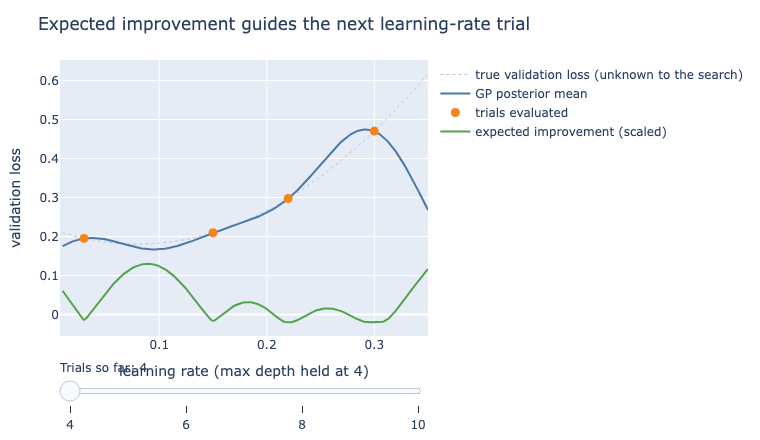

In [8]:
show(fig_expected_improvement())

## NGBoost: a boosted model that outputs a distribution

NGBoost's predicted mean (solid blue) tracks the point-estimate model's forecast (dashed red) closely at every payload size on the x-axis, but only NGBoost adds a shaded interval around it. That interval stays narrow inside the dense training-data region (roughly 5 to 25 KB) and widens sharply for payload sizes below and above it, since fewer training examples there leave the model less certain about the predicted rollback probability. Move the slider.

In [9]:
def fig_ngboost_predictive_width() -> go.Figure:
    x = np.linspace(0, 40, 200)  # payload size, kb
    train_range = (5, 25)  # where training data was dense

    point_estimate = 0.02 + 0.001 * x + 0.0006 * (x - 20) ** 2 / 20
    point_estimate = np.clip(point_estimate, 0, 1)

    dist_from_train = np.where(
        x < train_range[0], train_range[0] - x,
        np.where(x > train_range[1], x - train_range[1], 0.0),
    )
    ngboost_std = 0.02 + 0.006 * dist_from_train

    fractions = [0.0, 0.5, 1.0, 1.5, 2.0]
    frames = []
    for f in fractions:
        upper = np.clip(point_estimate + f * ngboost_std, 0, 1)
        lower = np.clip(point_estimate - f * ngboost_std, 0, 1)
        frames.append(
            go.Frame(
                name=f"{f:.1f}",
                data=[
                    go.Scatter(x=np.concatenate([x, x[::-1]]),
                               y=np.concatenate([upper, lower[::-1]]),
                               fill="toself", fillcolor="rgba(76,120,168,0.25)",
                               line=dict(color="rgba(255,255,255,0)"),
                               name="NGBoost predictive interval", showlegend=(f > 0)),
                    go.Scatter(x=x, y=point_estimate, mode="lines",
                               line=dict(color="#4C78A8", width=2),
                               name="NGBoost predicted mean"),
                    # Drawn after (on top of) the mean line above: the point-estimate model
                    # shares the same fitted curve in this simulation, so without this trace
                    # ordering its dashed red line renders fully hidden under the solid blue
                    # one. Drawing it last lets the dashes read as a visible pattern on top.
                    go.Scatter(x=x, y=point_estimate, mode="lines",
                               line=dict(color="#E45756", width=2, dash="dash"),
                               name="point-estimate boosted model"),
                ],
            )
        )

    # Default to a mid-strength interval (index 2 of 5, f=1.0) rather than f=0.0: at f=0 the
    # interval has zero width, so a reader who never touches the slider (including the static
    # PNG fallback) would see no interval at all, the opposite of what this figure is for.
    default_frame_idx = 2
    fig = go.Figure(data=frames[default_frame_idx].data, frames=frames)
    fig.update_layout(
        title="A point estimate does not know when it is extrapolating; NGBoost's interval does",
        xaxis_title="payload size (KB)",
        yaxis_title="predicted rollback probability",
        yaxis_range=[0, 1],
        shapes=[
            dict(type="rect", x0=train_range[0], x1=train_range[1], y0=0, y1=1,
                 fillcolor="rgba(84,162,75,0.08)", line=dict(width=0), layer="below"),
        ],
        annotations=[
            dict(x=(train_range[0] + train_range[1]) / 2, y=0.97, showarrow=False,
                 text="dense training data region", font=dict(size=11, color="#54A24B")),
        ],
        sliders=[{
            "active": default_frame_idx,
            "currentvalue": {"prefix": "Predictive interval width (std. multiples): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

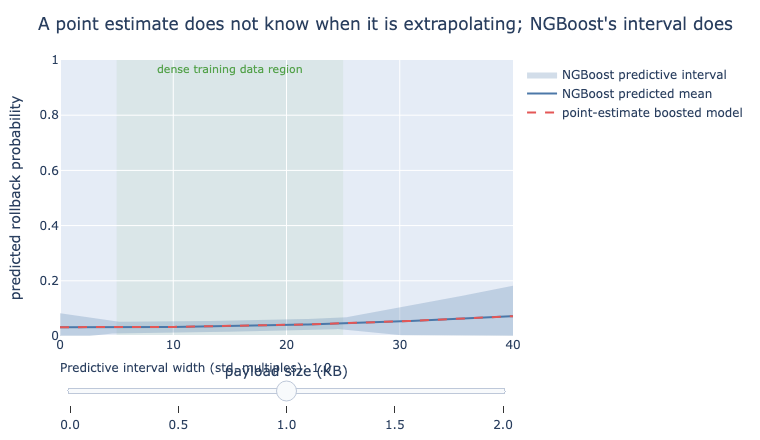

In [10]:
show(fig_ngboost_predictive_width())

## Setup: checkout-latency capacity scenario

Shared data for the quantile-regression and conformal-prediction figures below. Independent RNG (seed 47), so it never touches the draw sequence the three figures above depend on.

In [11]:
LATENCY_RNG = np.random.default_rng(47)
CAPACITY_RPS = 1800.0


def simulate_checkout_latency(n, rng):
    load = rng.uniform(50, 1700, n)
    utilization = load / CAPACITY_RPS
    mean_ms = 40 + 55 * utilization / (1 - 0.92 * utilization)
    # Gamma shape shrinks as utilization climbs, which fattens the right tail
    # and widens the spread precisely where queueing makes latency least
    # predictable, while scale is set so the mean always equals mean_ms.
    shape = np.clip(6.5 - 4.0 * utilization, 1.5, 6.5)
    scale = mean_ms / shape
    latency = rng.gamma(shape, scale, n)
    return load, latency

In [12]:
def _latency_splits():
    load, latency = simulate_checkout_latency(3000, LATENCY_RNG)
    idx = LATENCY_RNG.permutation(len(load))
    n_train, n_cal = 1200, 900
    train_idx = idx[:n_train]
    cal_idx = idx[n_train:n_train + n_cal]
    test_idx = idx[n_train + n_cal:]
    return (
        load[train_idx].reshape(-1, 1), latency[train_idx],
        load[cal_idx].reshape(-1, 1), latency[cal_idx],
        load[test_idx].reshape(-1, 1), latency[test_idx],
        load, latency,
    )

## Quantile regression: predicting the tail, not the average

Checkout latency against request load, with a fixed mean-regression line (dashed red) and a quantile-regression line (solid blue) that climbs as the target quantile rises. At 1,500 requests per second the mean line sits at 216 ms, comfortably under a 400 ms SLA; the 95th-percentile line sits at 434 ms, over it. Move the slider.

In [13]:
def fig_quantile_regression() -> go.Figure:
    from sklearn.ensemble import GradientBoostingRegressor

    X_train, y_train, _, _, _, _, load_all, latency_all = _latency_splits()

    mean_model = GradientBoostingRegressor(
        loss="squared_error", n_estimators=200, max_depth=3, learning_rate=0.05,
        random_state=0,
    )
    mean_model.fit(X_train, y_train)

    grid = np.linspace(60, 1690, 200)
    mean_curve = mean_model.predict(grid.reshape(-1, 1))

    sla_ms = 400.0
    quantile_levels = [0.50, 0.75, 0.90, 0.95, 0.99]
    frames = []
    for tau in quantile_levels:
        q_model = GradientBoostingRegressor(
            loss="quantile", alpha=tau, n_estimators=200, max_depth=3,
            learning_rate=0.05, random_state=0,
        )
        q_model.fit(X_train, y_train)
        q_curve = q_model.predict(grid.reshape(-1, 1))
        frames.append(
            go.Frame(
                name=f"{tau:.2f}",
                data=[
                    go.Scatter(
                        x=load_all, y=latency_all, mode="markers",
                        marker=dict(size=4, color="rgba(120,120,120,0.25)"),
                        name="observed (load, latency)", showlegend=False,
                    ),
                    go.Scatter(x=grid, y=mean_curve, mode="lines",
                               line=dict(color="#E45756", width=2, dash="dash"),
                               name="mean regression"),
                    go.Scatter(x=grid, y=q_curve, mode="lines",
                               line=dict(color="#4C78A8", width=3),
                               name=f"quantile regression (tau={tau:.2f})"),
                ],
            )
        )

    default_idx = 3  # tau = 0.95, the level the SLA story below is built on
    fig = go.Figure(data=frames[default_idx].data, frames=frames)
    fig.update_layout(
        title="Quantile regression tracks the tail; mean regression tracks the average",
        xaxis_title="request load (requests per second)",
        yaxis_title="checkout latency (ms)",
        shapes=[
            dict(type="line", x0=60, x1=1690, y0=sla_ms, y1=sla_ms,
                 line=dict(color="#54A24B", width=1.5, dash="dot")),
        ],
        annotations=[
            dict(x=120, y=sla_ms + 25, showarrow=False, text="400 ms SLA",
                 font=dict(size=11, color="#54A24B")),
        ],
        sliders=[{
            "active": default_idx,
            "currentvalue": {"prefix": "Quantile (tau): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate",
                                      "frame": {"duration": 300, "redraw": True},
                                      "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

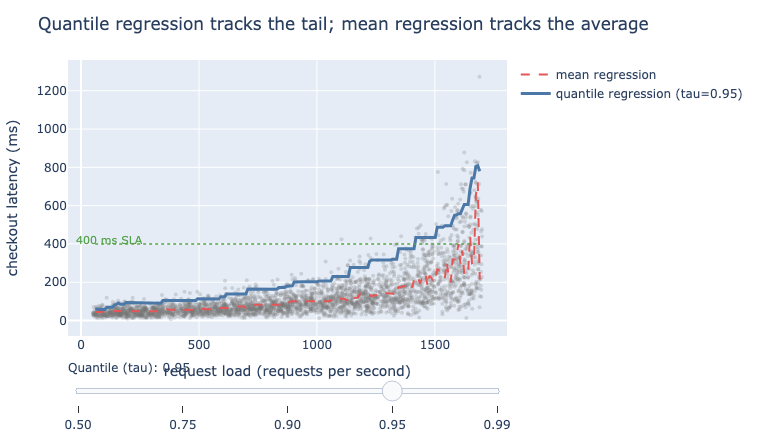

In [14]:
show(fig_quantile_regression())

## Conformal prediction: a coverage guarantee without a posterior

A fixed-width interval built from calibration residuals (dashed red) against a conformalized quantile-regression interval (shaded blue) at a 90% target. The fixed-width interval covers 92% of held-out points overall but only 74% in the busiest quarter of the load range; the conformalized interval holds close to 90% in both the busiest and the quietest quarter. Move the slider.

In [15]:
def fig_conformal_coverage() -> go.Figure:
    from sklearn.ensemble import GradientBoostingRegressor
    from scipy.stats import norm as scipy_norm

    X_train, y_train, X_cal, y_cal, X_test, y_test, _, _ = _latency_splits()

    mean_model = GradientBoostingRegressor(
        loss="squared_error", n_estimators=200, max_depth=3, learning_rate=0.05,
        random_state=0,
    )
    mean_model.fit(X_train, y_train)
    resid_cal = y_cal - mean_model.predict(X_cal)
    sigma = resid_cal.std()

    grid = np.linspace(60, 1690, 150)
    mean_grid = mean_model.predict(grid.reshape(-1, 1))
    top_q75 = float(np.percentile(X_test.ravel(), 75))
    bottom_q25 = float(np.percentile(X_test.ravel(), 25))

    coverage_targets = [0.80, 0.90, 0.95, 0.99]
    frames = []
    for target in coverage_targets:
        alpha = 1 - target
        lo_tau, hi_tau = alpha / 2, 1 - alpha / 2
        lo_model = GradientBoostingRegressor(
            loss="quantile", alpha=lo_tau, n_estimators=200, max_depth=3,
            learning_rate=0.05, random_state=0,
        )
        hi_model = GradientBoostingRegressor(
            loss="quantile", alpha=hi_tau, n_estimators=200, max_depth=3,
            learning_rate=0.05, random_state=0,
        )
        lo_model.fit(X_train, y_train)
        hi_model.fit(X_train, y_train)

        lo_cal, hi_cal = lo_model.predict(X_cal), hi_model.predict(X_cal)
        scores = np.maximum(lo_cal - y_cal, y_cal - hi_cal)
        n_cal = len(scores)
        q_level = np.clip(np.ceil((n_cal + 1) * (1 - alpha)) / n_cal, 0, 1)
        q_hat = float(np.quantile(scores, q_level))

        lo_grid = lo_model.predict(grid.reshape(-1, 1)) - q_hat
        hi_grid = hi_model.predict(grid.reshape(-1, 1)) + q_hat

        lo_test, hi_test = lo_model.predict(X_test) - q_hat, hi_model.predict(X_test) + q_hat
        cqr_cover = (y_test >= lo_test) & (y_test <= hi_test)

        z = scipy_norm.ppf(1 - alpha / 2)
        half_width = z * sigma
        naive_lo_test = mean_model.predict(X_test) - half_width
        naive_hi_test = mean_model.predict(X_test) + half_width
        naive_cover = (y_test >= naive_lo_test) & (y_test <= naive_hi_test)

        top_mask = X_test.ravel() > top_q75
        bottom_mask = X_test.ravel() < bottom_q25

        caption = (
            f"target {target:.0%} | CQR coverage: overall {cqr_cover.mean():.0%}, "
            f"busiest quarter {cqr_cover[top_mask].mean():.0%}, "
            f"quietest quarter {cqr_cover[bottom_mask].mean():.0%} &nbsp;|&nbsp; "
            f"naive coverage: overall {naive_cover.mean():.0%}, "
            f"busiest quarter {naive_cover[top_mask].mean():.0%}, "
            f"quietest quarter {naive_cover[bottom_mask].mean():.0%}"
        )

        frames.append(
            go.Frame(
                name=f"{target:.2f}",
                data=[
                    go.Scatter(x=X_test.ravel(), y=y_test, mode="markers",
                               marker=dict(size=4, color="rgba(120,120,120,0.35)"),
                               name="held-out points", showlegend=False),
                    go.Scatter(x=np.concatenate([grid, grid[::-1]]),
                               y=np.concatenate([hi_grid, lo_grid[::-1]]),
                               fill="toself", fillcolor="rgba(76,120,168,0.25)",
                               line=dict(color="rgba(255,255,255,0)"),
                               name="conformalized quantile regression (CQR)"),
                    go.Scatter(x=grid, y=mean_grid + half_width, mode="lines",
                               line=dict(color="#E45756", width=1.5, dash="dash"),
                               name="naive fixed-width interval"),
                    go.Scatter(x=grid, y=mean_grid - half_width, mode="lines",
                               line=dict(color="#E45756", width=1.5, dash="dash"),
                               showlegend=False),
                ],
                layout=go.Layout(annotations=[
                    dict(x=0.5, y=1.10, xref="paper", yref="paper", showarrow=False,
                         text=caption, font=dict(size=11)),
                ]),
            )
        )

    default_idx = 1  # target 0.90, the level the prose below is built on
    fig = go.Figure(data=frames[default_idx].data, frames=frames,
                     layout=go.Layout(annotations=frames[default_idx].layout.annotations))
    fig.update_layout(
        title="A fixed-width interval looks fine on average and fails where load is highest",
        xaxis_title="request load (requests per second)",
        yaxis_title="checkout latency (ms)",
        margin=dict(t=100, l=60, r=30, b=50),
        sliders=[{
            "active": default_idx,
            "currentvalue": {"prefix": "Target coverage: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate",
                                      "frame": {"duration": 300, "redraw": True},
                                      "transition": {"duration": 0}}]}
                for f in frames
            ],
        }],
    )
    return fig

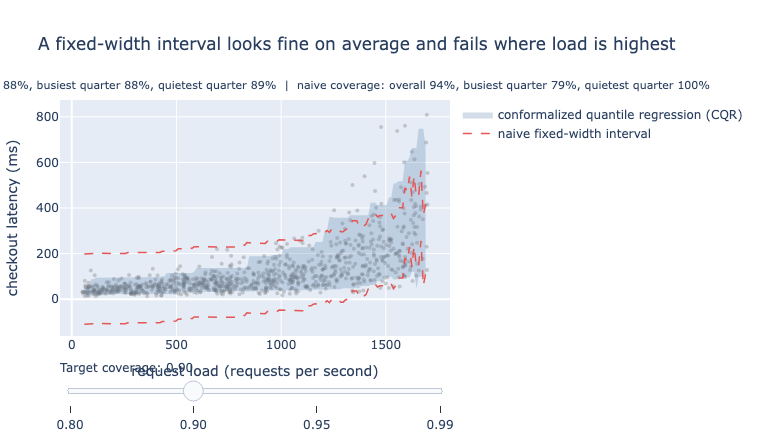

In [16]:
show(fig_conformal_coverage())